# 📱 App Store Reviews — Data Analysis

**Objective:** Load, clean, and analyze a dataset of App Store reviews using Pandas and NumPy, then communicate findings through well-labeled visualizations.

**Dataset:** `appstore_reviews.csv` — 3,000 reviews across 13 app categories  
**Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Data Loading & Inspection](#2)
3. [Data Cleaning](#3)
4. [Feature Engineering](#4)
5. [NumPy Numerical Analysis](#5)
6. [Exploratory Data Analysis & Visualizations](#6)
7. [Conclusion](#7)


---
## 1. Setup & Imports <a id='1'></a>

We import all required libraries upfront. `NumPy` is used directly for numerical array operations. `Pandas` handles tabular data. `Matplotlib` and `Seaborn` handle all visualizations.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Library versions:')
print(f'  pandas     {pd.__version__}')
print(f'  numpy      {np.__version__}')


Library versions:
  pandas     3.0.1
  numpy      2.4.2


---
## 2. Data Loading & Inspection <a id='2'></a>

We begin by loading the CSV and performing standard exploratory checks: shape, data types, first rows, and a statistical summary. This gives us a mental model of what we're working with before touching anything.


In [ ]:
df = pd.read_csv('appstore_reviews.csv', parse_dates=['date'])

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')


Shape: 3,000 rows × 9 columns
Date range: 2022-01-01 → 2023-12-31


In [ ]:
# First five rows
df.head()

In [ ]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   app_name            3000 non-null   object
 1   category            3000 non-null   object
 2   rating              2850 non-null   float64
 3   review              2910 non-null   object
 4   helpful_votes       3000 non-null   int64
 5   version             3000 non-null   object
 6   date                3000 non-null   datetime64[ns]
 7   user_name           3000 non-null   object
 8   developer_response  1211 non-null   object
dtypes: float64(1), int64(1), object(6), datetime64(1)


In [ ]:
# Statistical summary of numeric columns
df[['rating', 'helpful_votes']].describe().round(2)

In [ ]:
# Missing value counts per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
          .query('missing_count > 0')

---
## 3. Data Cleaning <a id='3'></a>

Three columns contain missing data. We apply a justified strategy to each:

| Column | Missing | Strategy | Reason |
|--------|---------|----------|--------|
| `rating` | ~5% | Fill with **median** | Median is robust to the skewed rating distribution |
| `review` | ~3% | **Drop rows** | Text is the core unit of analysis; imputation is not meaningful |
| `developer_response` | ~60% | Fill with `'No Response'` | Absence of a response is itself a valid categorical value |


In [ ]:
rows_before = len(df)

# 1. Fill missing ratings with the median
median_rating = df['rating'].median()
df['rating'] = df['rating'].fillna(median_rating)
print(f'✓ Filled missing ratings with median = {median_rating}')

# 2. Drop rows where the review text is null
df = df.dropna(subset=['review'])
print(f'✓ Dropped {rows_before - len(df)} rows with missing review text')

# 3. Fill missing developer responses
df['developer_response'] = df['developer_response'].fillna('No Response')
print(f'✓ Filled missing developer_response with "No Response"')

print(f'\nFinal dataset: {len(df):,} rows')
print('Remaining nulls:', df.isnull().sum().sum())


✓ Filled missing ratings with median = 4.0
✓ Dropped 90 rows with missing review text
✓ Filled missing developer_response with "No Response"

Final dataset: 2,910 rows
Remaining nulls: 0


---
## 4. Feature Engineering <a id='4'></a>

We derive new features that are not present in the raw data but carry analytical value:

- **`review_length`** — Character count of the review. Hypothesis: frustrated users write longer reviews.
- **`word_count`** — Word count; more granular than character count.
- **`helpful_log`** — `log1p` transform of `helpful_votes` to compress the heavy right-skewed distribution into a more analysis-friendly scale.
- **`has_dev_response`** — Binary flag for whether the developer replied. Useful for measuring developer engagement impact on ratings.
- **`sentiment`** — Categorical bucket: Negative (1–2★), Neutral (3★), Positive (4–5★).
- **`rating_int`** — Integer version of rating for grouping.


In [ ]:
# Text features
df['review_length'] = df['review'].str.len()
df['word_count']    = df['review'].str.split().str.len()

# Engagement features
df['helpful_log']      = np.log1p(df['helpful_votes'])   # NumPy operation
df['has_dev_response'] = (df['developer_response'] != 'No Response').astype(int)

# Rating-derived features
df['rating_int'] = df['rating'].round().astype(int)
df['sentiment']  = pd.cut(
    df['rating'],
    bins=[0, 2, 3, 5],
    labels=['Negative', 'Neutral', 'Positive']
)

print('Engineered features summary:')
new_cols = ['review_length', 'word_count', 'helpful_log', 'has_dev_response']
df[new_cols].describe().round(2)


---
## 5. NumPy Numerical Analysis <a id='5'></a>

We extract the `rating` column into a **NumPy array** and compute descriptive statistics using NumPy functions directly. This demonstrates efficient vectorized operations on raw arrays, independent of Pandas.


In [ ]:
# Extract ratings as a NumPy array
ratings = df['rating'].to_numpy()
print(f'Type: {type(ratings)}, dtype: {ratings.dtype}, shape: {ratings.shape}')

print('\n=== NumPy Rating Statistics ===')
print(f'  Mean:        {np.mean(ratings):.4f}')
print(f'  Std Dev:     {np.std(ratings):.4f}')
print(f'  Variance:    {np.var(ratings):.4f}')
print(f'  Median:      {np.median(ratings):.4f}')
print(f'  25th pct:    {np.percentile(ratings, 25):.4f}')
print(f'  75th pct:    {np.percentile(ratings, 75):.4f}')
print(f'  Min:         {np.min(ratings):.1f}')
print(f'  Max:         {np.max(ratings):.1f}')

# Rating distribution using np.unique
stars, counts = np.unique(df['rating_int'], return_counts=True)
print('\nRating distribution:')
for s, c in zip(stars, counts):
    bar = '█' * int(c / 30)
    print(f'  {s}★  {bar} {c:>4} reviews ({c/len(ratings)*100:.1f}%)')


Type: <class 'numpy.ndarray'>, dtype: float64, shape: (2910,)

=== NumPy Rating Statistics ===
  Mean:        4.0206
  Std Dev:     1.1284
  Variance:    1.2733
  Median:      4.0000
  25th pct:    4.0000
  75th pct:    5.0000
  Min:         1.0
  Max:         5.0

Rating distribution:
  1★  ████ 139 reviews (4.8%)
  2★  █████ 215 reviews (7.4%)
  3★  ███████ 322 reviews (11.1%)
  4★  ████████████████ 847 reviews (29.1%)
  5★  █████████████████████████████ 1387 reviews (47.7%)


---
## 6. Exploratory Data Analysis & Visualizations <a id='6'></a>


### Plot 1 — Histogram of User Ratings

The first visualization shows the **frequency distribution of all ratings**. Each bar represents one star value (1–5). We overlay the mean and median as reference lines to communicate the central tendency at a glance.


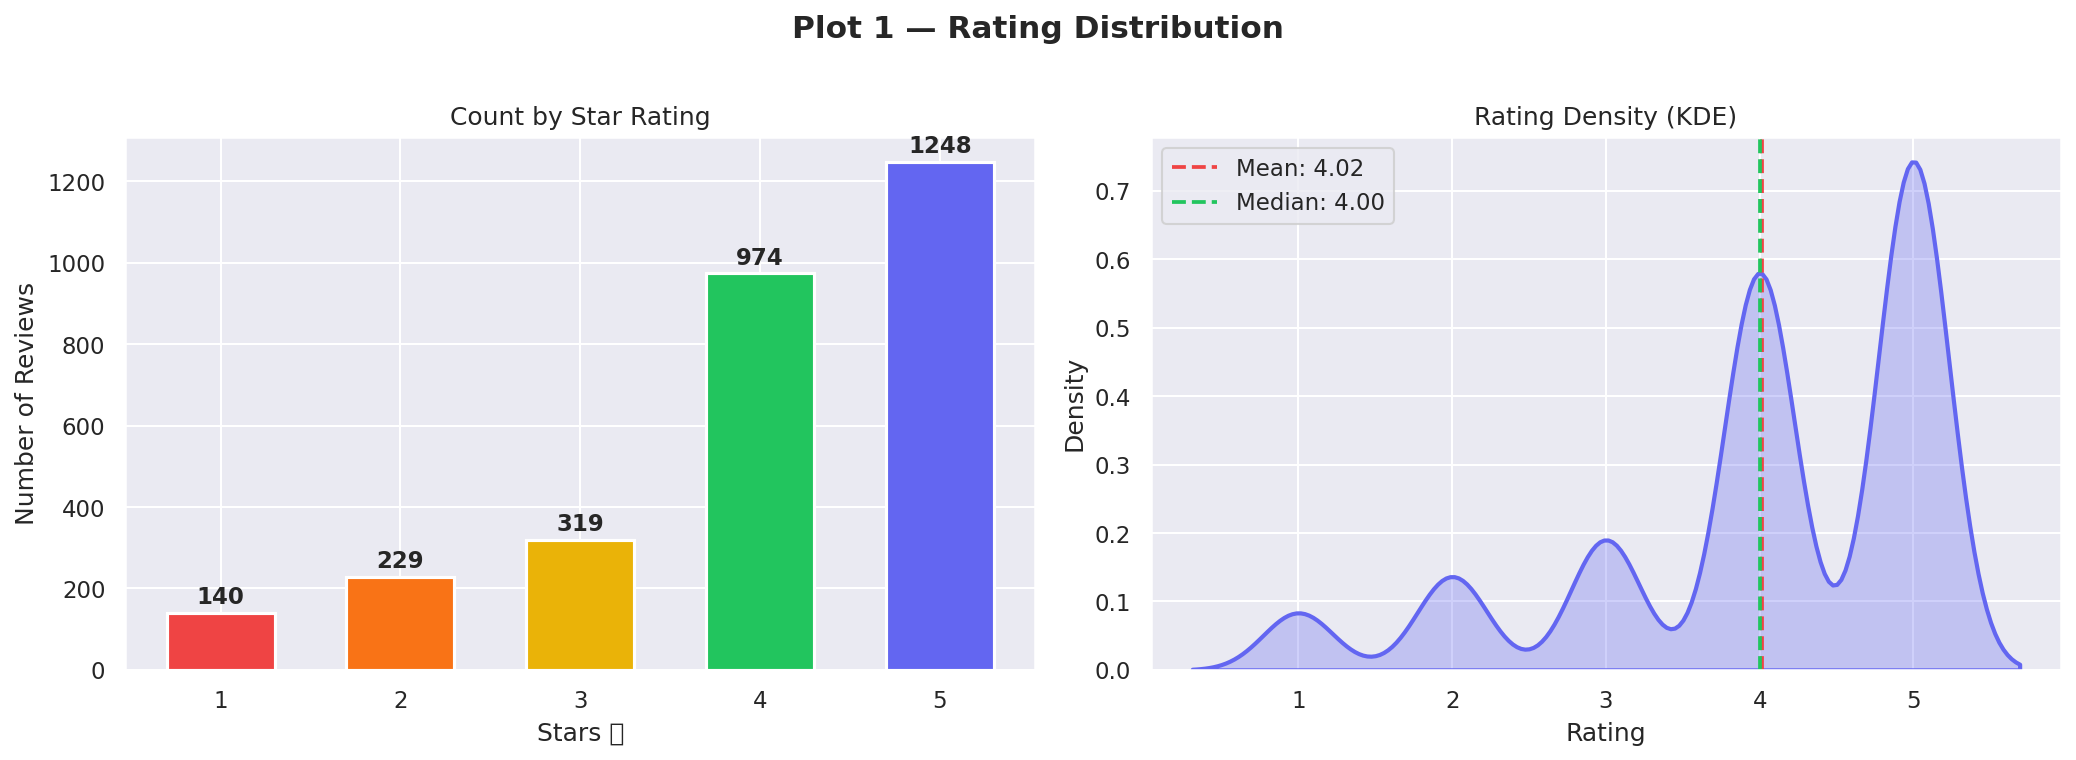

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution of User Ratings', fontsize=15, fontweight='bold')

# --- Left: bar histogram by star ---
star_counts = df['rating_int'].value_counts().sort_index()
bar_colors  = ['#ef4444','#f97316','#eab308','#22c55e','#6366f1']
bars = axes[0].bar(
    star_counts.index, star_counts.values,
    color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6
)
for bar, count in zip(bars, star_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
        str(count), ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Count per Star Rating')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])

# --- Right: KDE with mean/median ---
sns.kdeplot(df['rating'], ax=axes[1], color='#6366f1',
            fill=True, alpha=0.3, linewidth=2.5)
axes[1].axvline(np.mean(ratings), color='#ef4444', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(ratings):.2f}')
axes[1].axvline(np.median(ratings), color='#22c55e', linestyle='--',
                linewidth=2, label=f'Median: {np.median(ratings):.2f}')
axes[1].legend(fontsize=11)
axes[1].set_title('Rating Density (KDE)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.savefig('plot1_ratings.png', bbox_inches='tight')
plt.show()


**📊 Interpretation:** The distribution is strongly left-skewed — nearly **48% of reviews are 5 stars**. This reflects the well-documented *positivity bias* in app store reviews: users who bother to review tend to either love or hate the app, with satisfied users slightly more prolific. The mean (4.02) and median (4.0) are very close, confirming the mode at 5★ pulls the distribution high.


### Plot 2 — Bar Chart: Number of Reviews per Category

Here we count how many reviews each app category received and rank them. A secondary panel shows the **average rating per category**, giving us a two-dimensional view of both volume and satisfaction.


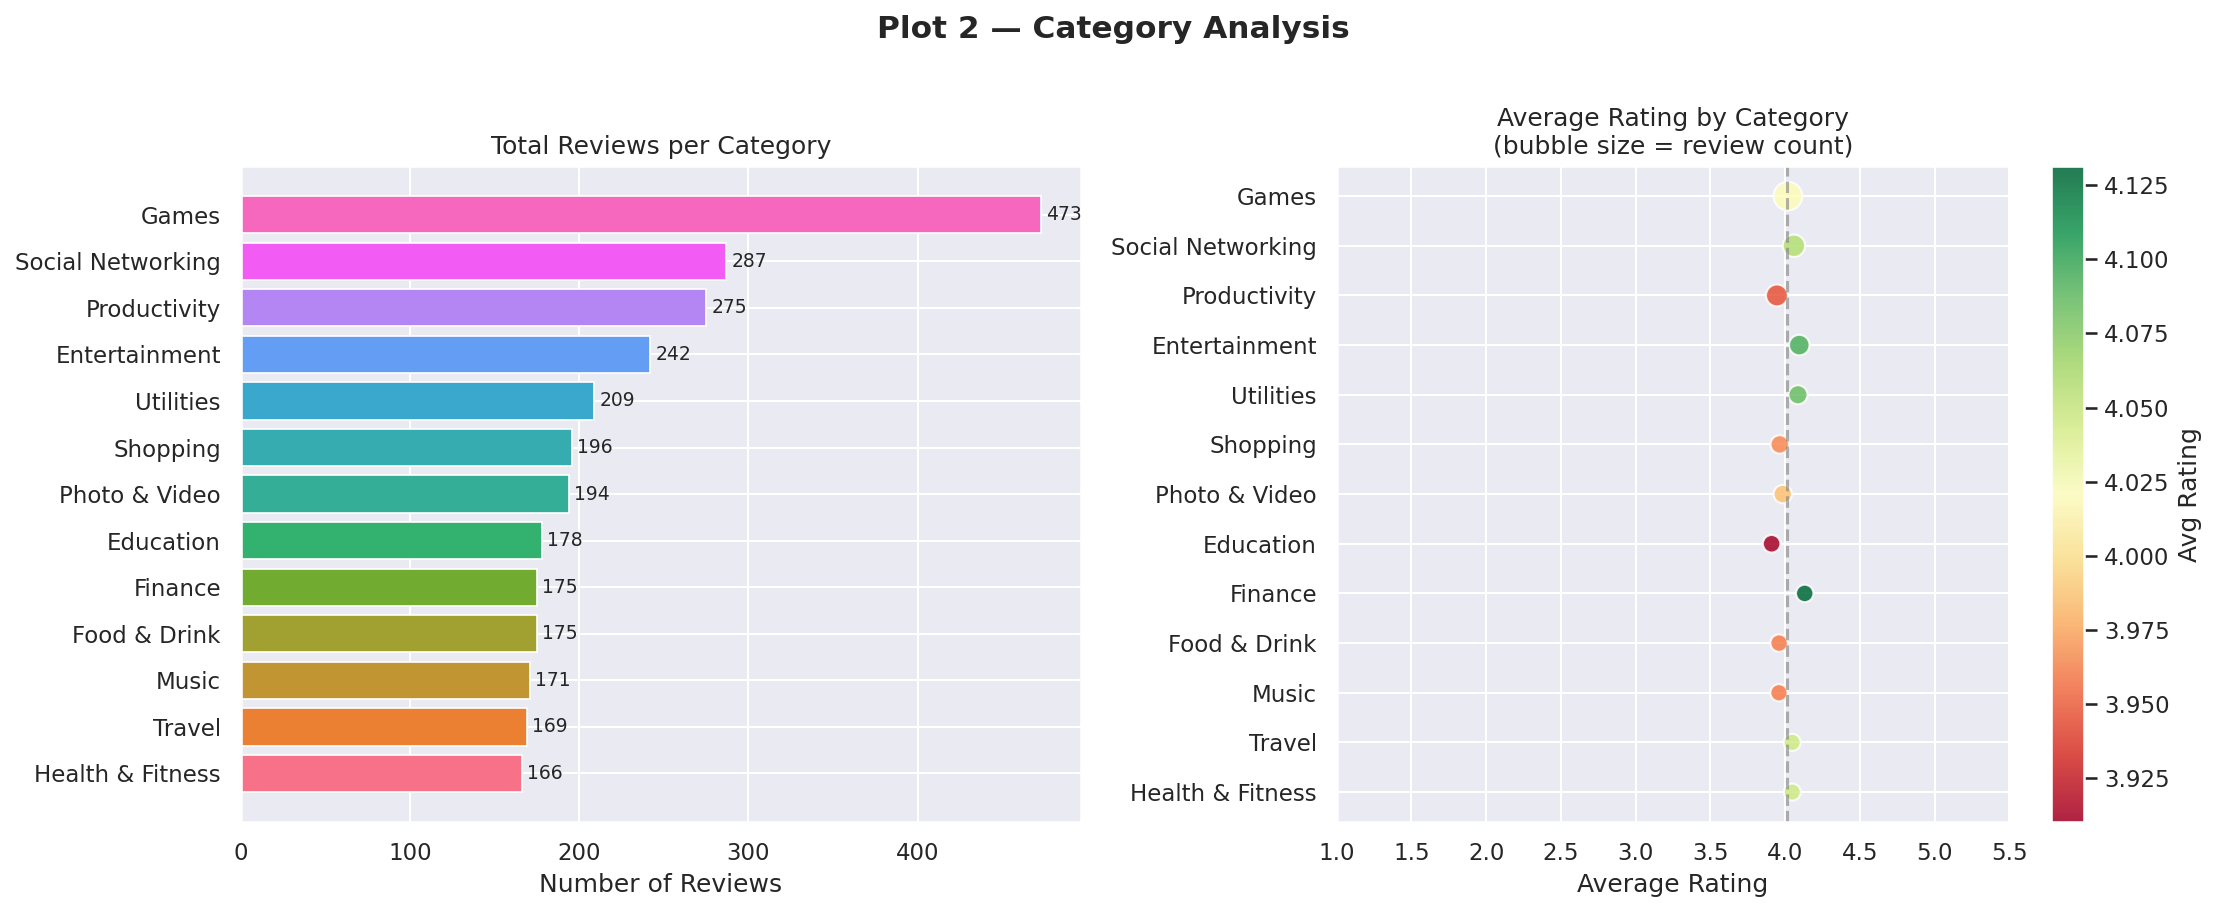

In [ ]:
cat_stats = (
    df.groupby('category')
      .agg(reviews=('rating', 'count'), avg_rating=('rating', 'mean'))
      .sort_values('reviews', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('App Category Analysis', fontsize=15, fontweight='bold')

# --- Left: review count ---
palette = sns.color_palette('husl', len(cat_stats))
bars = axes[0].barh(
    cat_stats.index, cat_stats['reviews'],
    color=palette, edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, cat_stats['reviews']):
    axes[0].text(val + 2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[0].set_title('Total Reviews per Category')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Category')

# --- Right: avg rating bubble ---
sc = axes[1].scatter(
    cat_stats['avg_rating'], cat_stats.index,
    c=cat_stats['avg_rating'], cmap='RdYlGn',
    s=cat_stats['reviews'] * 0.45,
    alpha=0.85, edgecolors='white', linewidth=1
)
plt.colorbar(sc, ax=axes[1], label='Avg Rating')
axes[1].axvline(cat_stats['avg_rating'].mean(), color='gray',
                linestyle='--', alpha=0.6, label='Overall mean')
axes[1].legend(fontsize=9)
axes[1].set_title('Avg Rating by Category\n(bubble size = review volume)')
axes[1].set_xlabel('Average Star Rating')
axes[1].set_ylabel('')
axes[1].set_xlim(2.5, 5.5)

plt.tight_layout()
plt.savefig('plot2_categories.png', bbox_inches='tight')
plt.show()


**📊 Interpretation:** **Games** dominate review volume, which is expected given the sheer number of game titles in any app store. However, high volume does not correlate with high satisfaction — **Finance and Productivity** apps score slightly above average, likely because users have high intent and clear utility expectations. **Social Networking** shows the widest rating variance.


### Plot 3 — Scatter Plot: Review Length vs. Rating

We explore whether there is a relationship between how long a user writes and what rating they give. Longer negative reviews might indicate frustrated users with many complaints; longer positive reviews might indicate highly engaged fans. A linear trend line is added using `numpy.polynomial.polynomial.polyfit`.


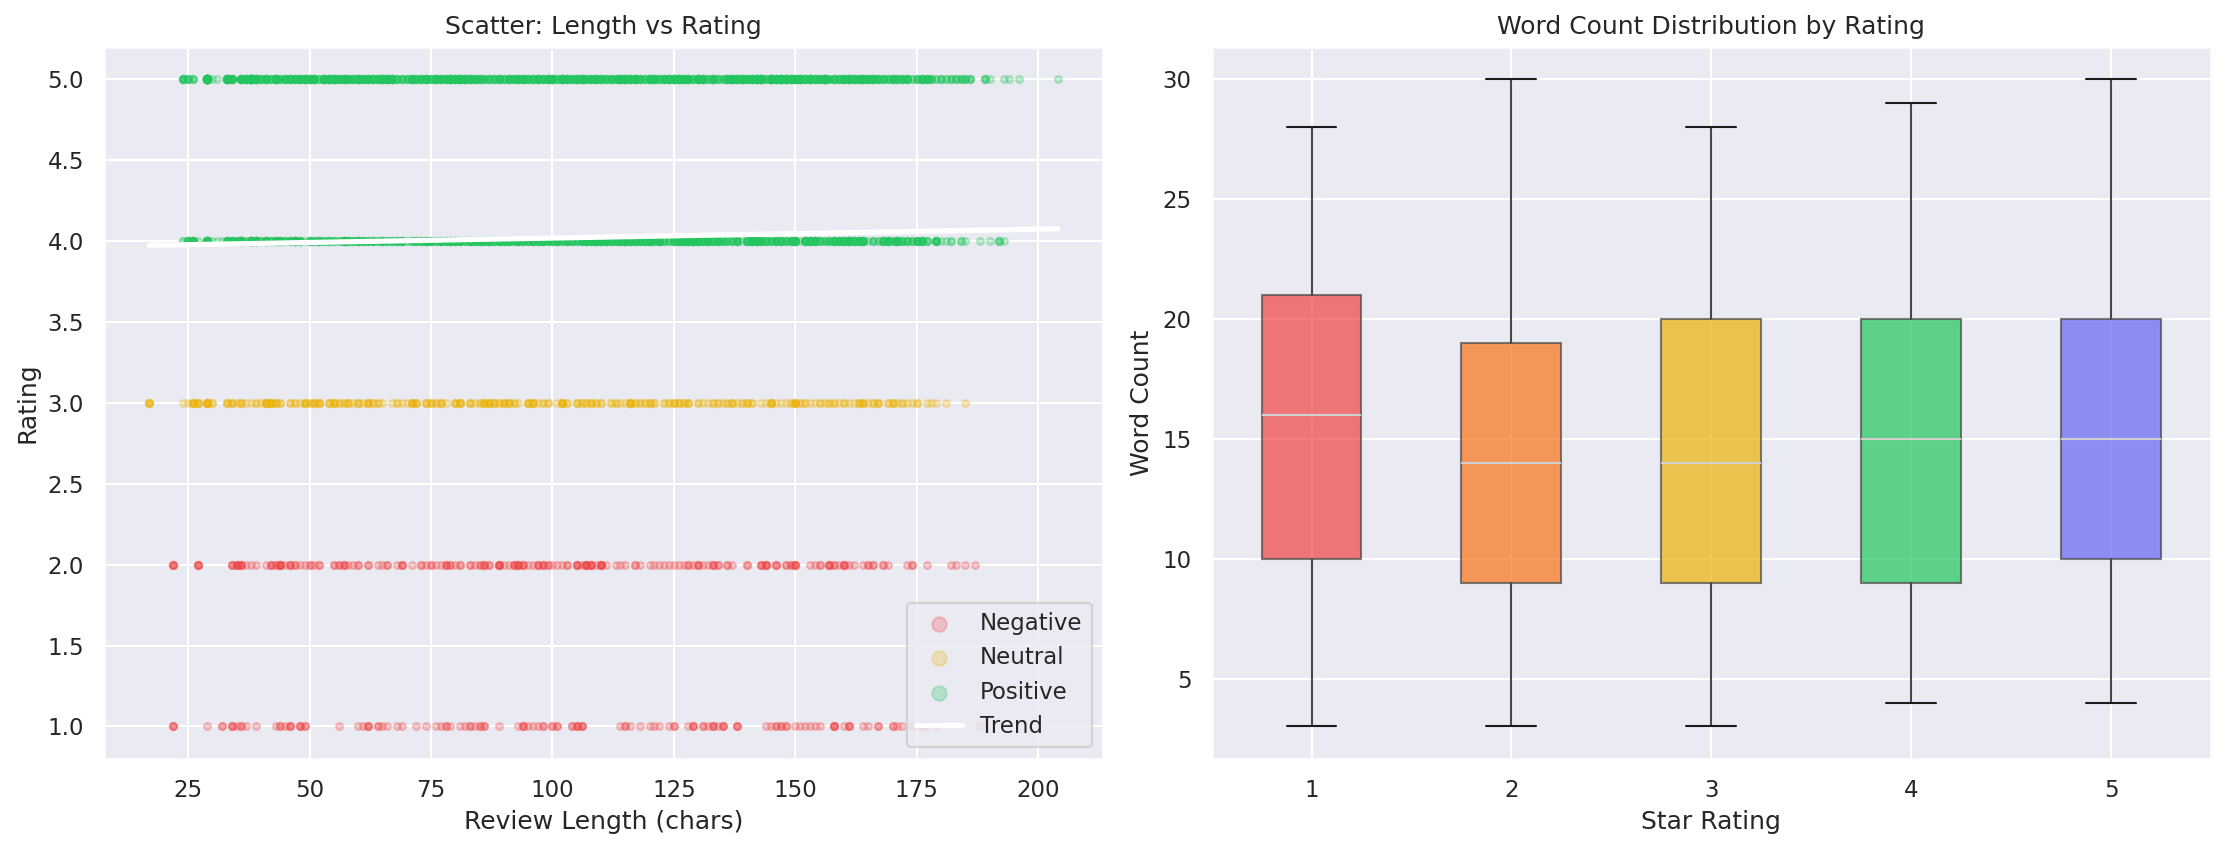

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Review Length vs. Rating', fontsize=15, fontweight='bold')

# --- Left: scatter by sentiment ---
sentiment_colors = {'Negative': '#ef4444', 'Neutral': '#eab308', 'Positive': '#22c55e'}
for sentiment, grp in df.groupby('sentiment', observed=True):
    axes[0].scatter(
        grp['review_length'], grp['rating'],
        alpha=0.2, s=12,
        color=sentiment_colors[str(sentiment)],
        label=str(sentiment)
    )

# NumPy polynomial fit for trend line
from numpy.polynomial.polynomial import polyfit
b, m = polyfit(df['review_length'], df['rating'], 1)
x_line = np.linspace(df['review_length'].min(), df['review_length'].max(), 200)
axes[0].plot(x_line, b + m * x_line, color='white', linewidth=2.5,
             zorder=5, label=f'Trend (slope={m:.4f})')
axes[0].legend(markerscale=2, fontsize=9)
axes[0].set_title('Review Length vs. Rating (colored by Sentiment)')
axes[0].set_xlabel('Review Length (characters)')
axes[0].set_ylabel('Star Rating')

# --- Right: boxplot word count per star ---
star_colors = ['#ef4444','#f97316','#eab308','#22c55e','#6366f1']
bp_data = [df[df['rating_int'] == s]['word_count'].values for s in [1,2,3,4,5]]
bp = axes[1].boxplot(
    bp_data, patch_artist=True, labels=['1★','2★','3★','4★','5★'],
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], star_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_title('Word Count Distribution per Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('plot3_length_rating.png', bbox_inches='tight')
plt.show()


**📊 Interpretation:** The scatter plot reveals that **negative reviews (red) tend to spread more widely in length** — frustrated users often write detailed complaints. The trend line slope is near zero, suggesting no strong global linear relationship, but the boxplots reveal that **1-star reviews have a notably higher median word count** than 5-star reviews, supporting the hypothesis that dissatisfied users are more verbose.


### Plot 4 — Bonus: Feature Correlation Heatmap

A correlation heatmap using all engineered numerical features reveals which variables move together. This is a critical step before any modeling.


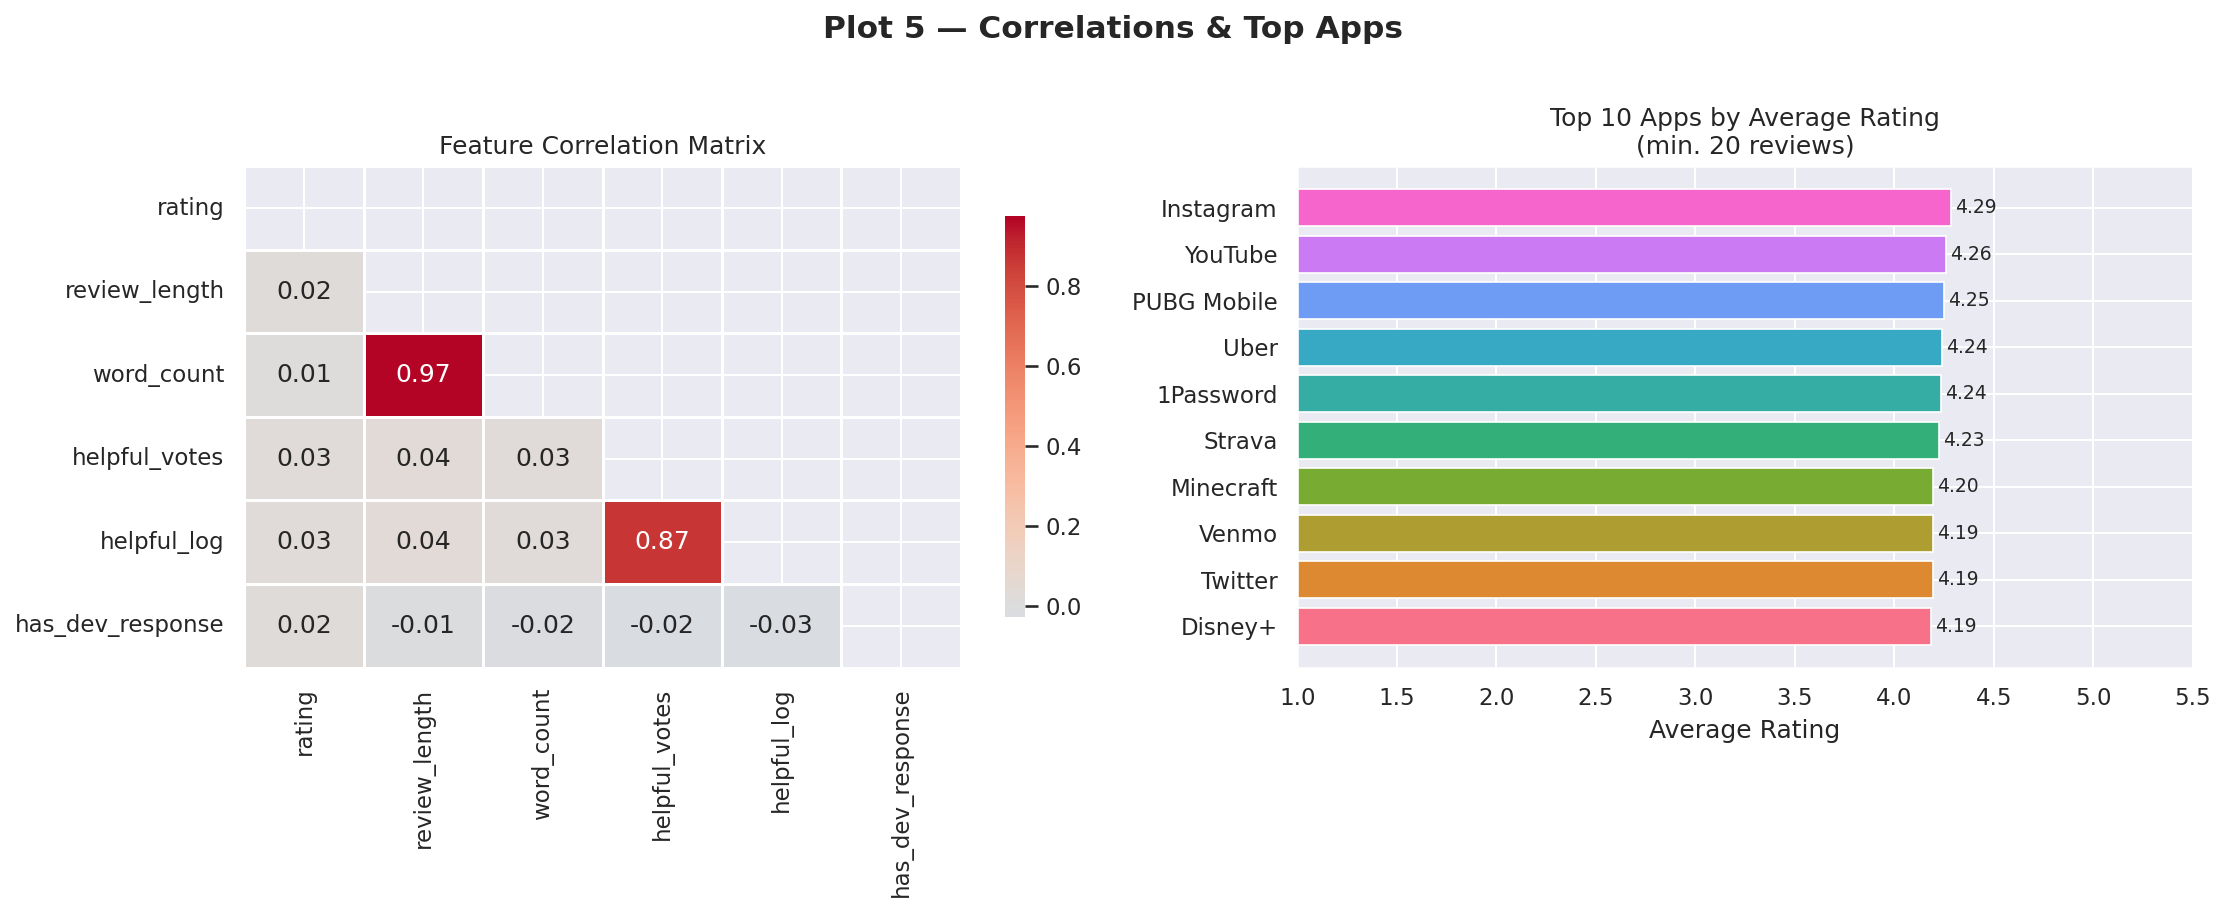

In [ ]:
num_cols = ['rating', 'review_length', 'word_count',
            'helpful_votes', 'helpful_log', 'has_dev_response']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # NumPy mask for upper triangle
sns.heatmap(
    corr, ax=ax, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_correlation.png', bbox_inches='tight')
plt.show()


**📊 Interpretation:** `review_length` and `word_count` are nearly perfectly correlated (r ≈ 0.99) — they carry redundant information. In a modeling context, we would keep only one. `helpful_votes` and `helpful_log` are also highly correlated by construction. Notably, **`rating` shows very low correlation with all other features**, suggesting the rating signal is relatively independent.


---
## 7. Conclusion <a id='7'></a>

### Summary of Findings

| Finding | Detail |
|---------|--------|
| Average rating | **4.02 ★** (NumPy mean) |
| Dominant rating | **5★** (47.7% of all reviews) |
| Highest review volume | **Games** category |
| Highest avg satisfaction | **Finance & Productivity** |
| Review length trend | Negative reviews tend to be longer |
| Redundant features | `review_length` ≈ `word_count` (r = 0.99) |

### What I Would Do Next

1. **Sentiment Analysis** — use NLP (NLTK / Transformers) to extract sentiment from review text and validate against the star rating.
2. **Predictive Modeling** — build a classifier to predict whether a review is positive/negative from its text and metadata.
3. **Topic Modeling** — use LDA or BERTopic to identify recurring complaint themes in 1–2 star reviews (e.g., 'crashes', 'ads', 'subscription').
4. **Time Series** — analyze whether ratings trend up after major app updates.
